In [14]:
import numpy as np
import torch
import torch.nn as nn

### Data preparation
data = np.genfromtxt('iris_2D_demo.csv', delimiter=',', skip_header=1)
X = torch.from_numpy(data[:,0:2]).float()
y = torch.from_numpy(data[:,2:]).float()

print('X\n', X)
print('y\n', y)

X
 tensor([[1.4000, 0.2000],
        [1.5000, 0.2000],
        [3.0000, 1.1000],
        [4.1000, 1.3000]])
y
 tensor([[0.],
        [0.],
        [1.],
        [1.]])


In [23]:
# Create a linear layer
linear = nn.Linear(2, 1)

# set value (for illustration)
linear.weight.data = torch.Tensor([[0.5, -0.1]])
linear.bias.data = torch.Tensor([0.1])

# print
print(linear.weight)
print(linear.bias)

Parameter containing:
tensor([[ 0.5000, -0.1000]], requires_grad=True)
Parameter containing:
tensor([0.1000], requires_grad=True)


### Using nn.CrossEntropyLoss

In [38]:
# Create a linear layer
linear = nn.Linear(2, 1)

# some params
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.SGD(linear.parameters(), 
                            lr=0.1)
epochs = 2000

# training
losses = []
for epoch in range(epochs):        
    # y_hat
    y_hat = torch.sigmoid(linear(X))
    
    # loss        
    loss = loss_fn(y_hat, y)
    losses.append(loss.item())
                
    # compute gradient
    optimizer.zero_grad()
    loss.backward()

    # update
    optimizer.step()

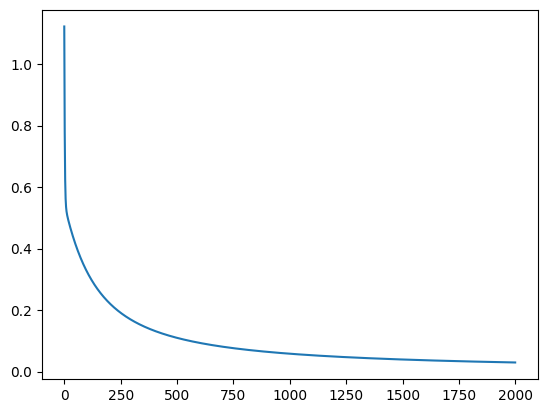

In [39]:
import matplotlib.pyplot as plt
plt.plot(losses)

In [40]:
# compute accuracy 
z = linear(X)
y_hat = nn.Sigmoid()(z)

# compute accuracy using y and y_hat
y_hat_rounded = y_hat.round()
acc = (y_hat_rounded == y).float().mean()
print(acc)

tensor(1.)


### Using nn.BCEWithLogitsLoss (the sigmoid function is called automatically inside the loss)

In [28]:
# Create a linear layer
linear = nn.Linear(2, 1)

# some params
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(linear.parameters(), 
                            lr=0.1)
epochs = 2000

# training
losses = []
for epoch in range(epochs):        
    # y_hat
    z = linear(X)
    
    # loss        
    loss = loss_fn(z, y)
    losses.append(loss.item())
                
    # compute gradient
    optimizer.zero_grad()
    loss.backward()

    # update
    optimizer.step()

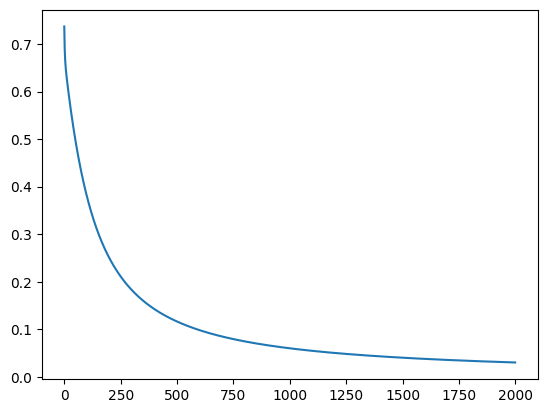

In [29]:
import matplotlib.pyplot as plt
plt.plot(losses)

In [37]:
# compute accuracy 
z = linear(X)
y_hat = nn.Sigmoid()(z)

# compute accuracy using y and y_hat
y_hat_rounded = y_hat.round()
acc = (y_hat_rounded == y).float().mean()
print(acc)

tensor(1.)
